## CONV2

### 1 CAPA

In [1]:
import os 
import numpy as np  
from PIL import Image  
import tensorflow as tf  
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense  # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping  # Importa el callback

2025-09-19 15:18:57.130500: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-19 15:18:57.130817: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-19 15:18:57.162952: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-19 15:18:57.898387: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Redimensionar imágenes

In [2]:
# Directorio original y reducido
d_original = '/media/smoke/SSD_D0/bandas/banda13/ene_01'
d_reducida = '/media/smoke/SSD_D0/bandas/banda13/ene_01_reducida_test'

# Función de redimensionado - TAMAÑO PEQUEÑO PARA PRUEBAS
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))  # Redimensiona la imagen
            np.save(os.path.join(d_reducida, filename), img_resized)  # Guarda la imagen redimensionada

In [3]:
# Redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar las 23 imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

# Modelo secuencial simple
# model = Sequential([
#     Conv2D(8, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
#     Conv2D(4, (3, 3), activation='relu', padding='same'),
#     Conv2D(1, (3, 3), activation='linear', padding='same')
# ])

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    Conv2D(1, (3, 3), activation='linear', padding='same')
])

# model = Sequential([
#     Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
#     Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
#     Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
#     Conv2D(1, kernel_size=(3, 3), activation='linear', padding='same')
# ])

model.compile(optimizer='adam', loss='mae', metrics=['mae'])

print("Resumen del modelo:")
model.summary()

# Entrenamiento rápido - solo 3 épocas
print("Iniciando entrenamiento de prueba...")

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X, y,
    epochs=50,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)
print("¡Prueba completada!")
print(f"Pérdida final: {history.history['loss'][-1]:.4f}")

Procesando 23 imágenes
Forma de X: (22, 480, 480, 1)
Forma de y: (22, 480, 480, 1)
Resumen del modelo:


/home/smoke/datac/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-09-19 15:19:05.416342: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 480, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 480, 480, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,529 (181.75 KB)

 Trainable params: 46,529 (181.75 KB)

 Non-trainable params: 0 (0.00 B)

Iniciando entrenamiento de prueba...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 0.6867 - mae: 0.6867
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.5654 - mae: 0.5654
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.2254 - mae: 0.2254
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.1811 - mae: 0.1811
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.1522 - mae: 0.1522
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.1332 - mae: 0.1332
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.1335 - mae: 0.1335
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 0.1000 - mae: 0.1000
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 0.1158 - mae: 0.1158
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 0.0909 - mae: 0.0909
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.0868 - mae: 0.0868
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.0855 - mae: 0.0855
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step


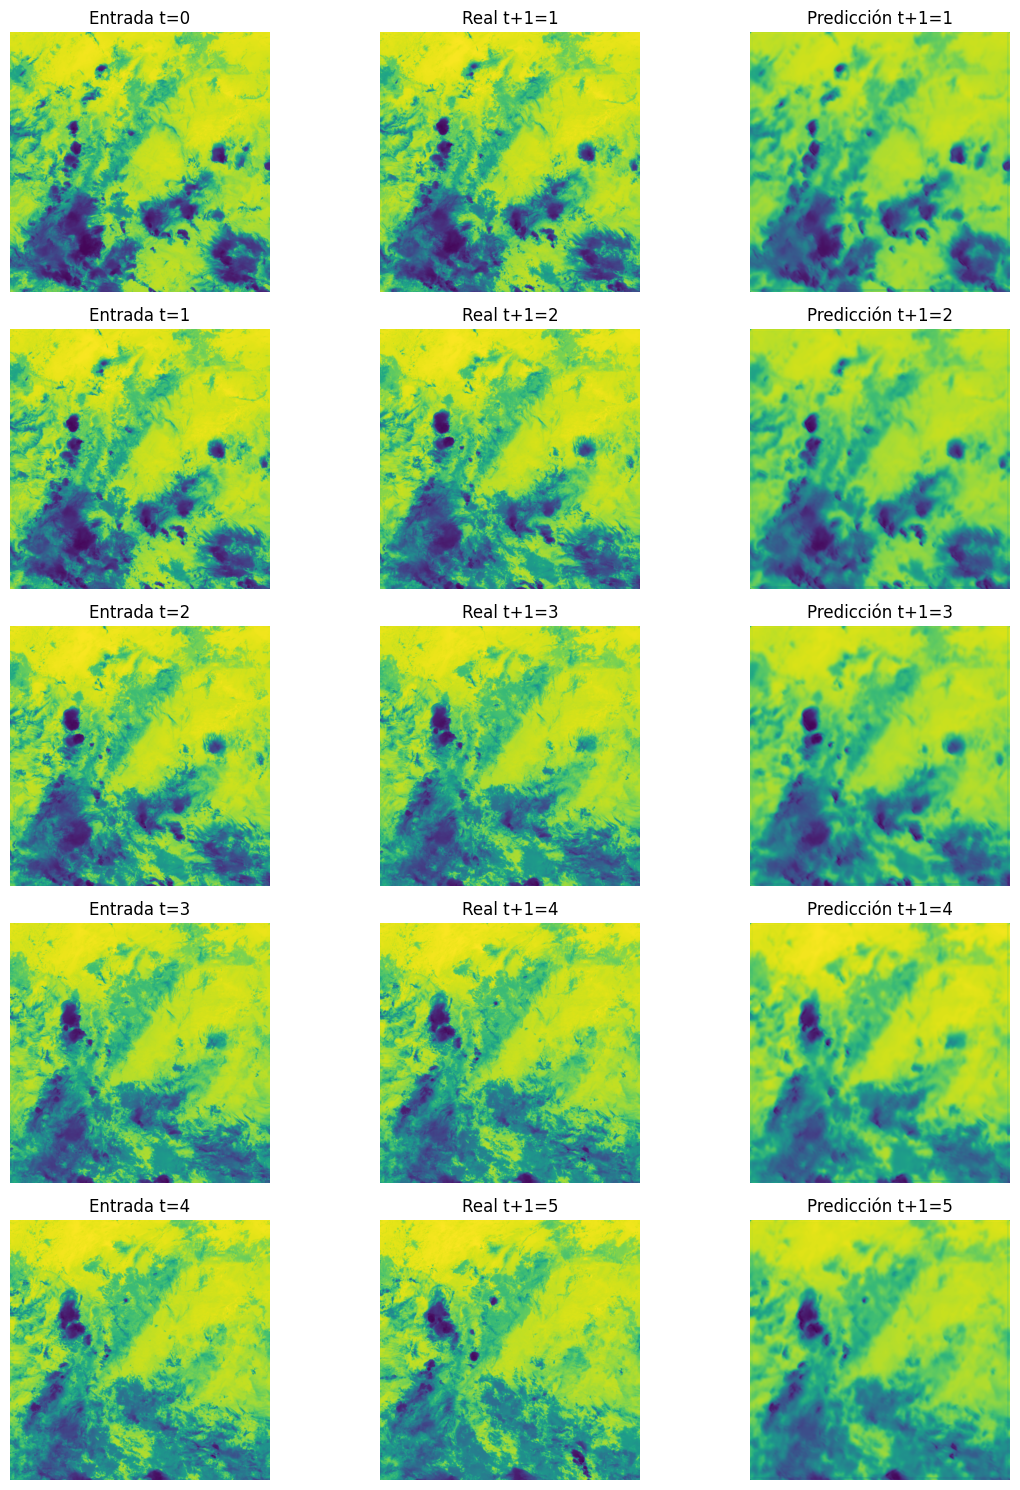

In [4]:
import matplotlib.pyplot as plt

# Selecciona el número de ejemplos a mostrar
n = 5

y_pred = model.predict(X)  # Genera las predicciones

# Muestra imágenes reales vs predichas usando un mapa de color
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y[i, ..., 0], cmap='viridis')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step


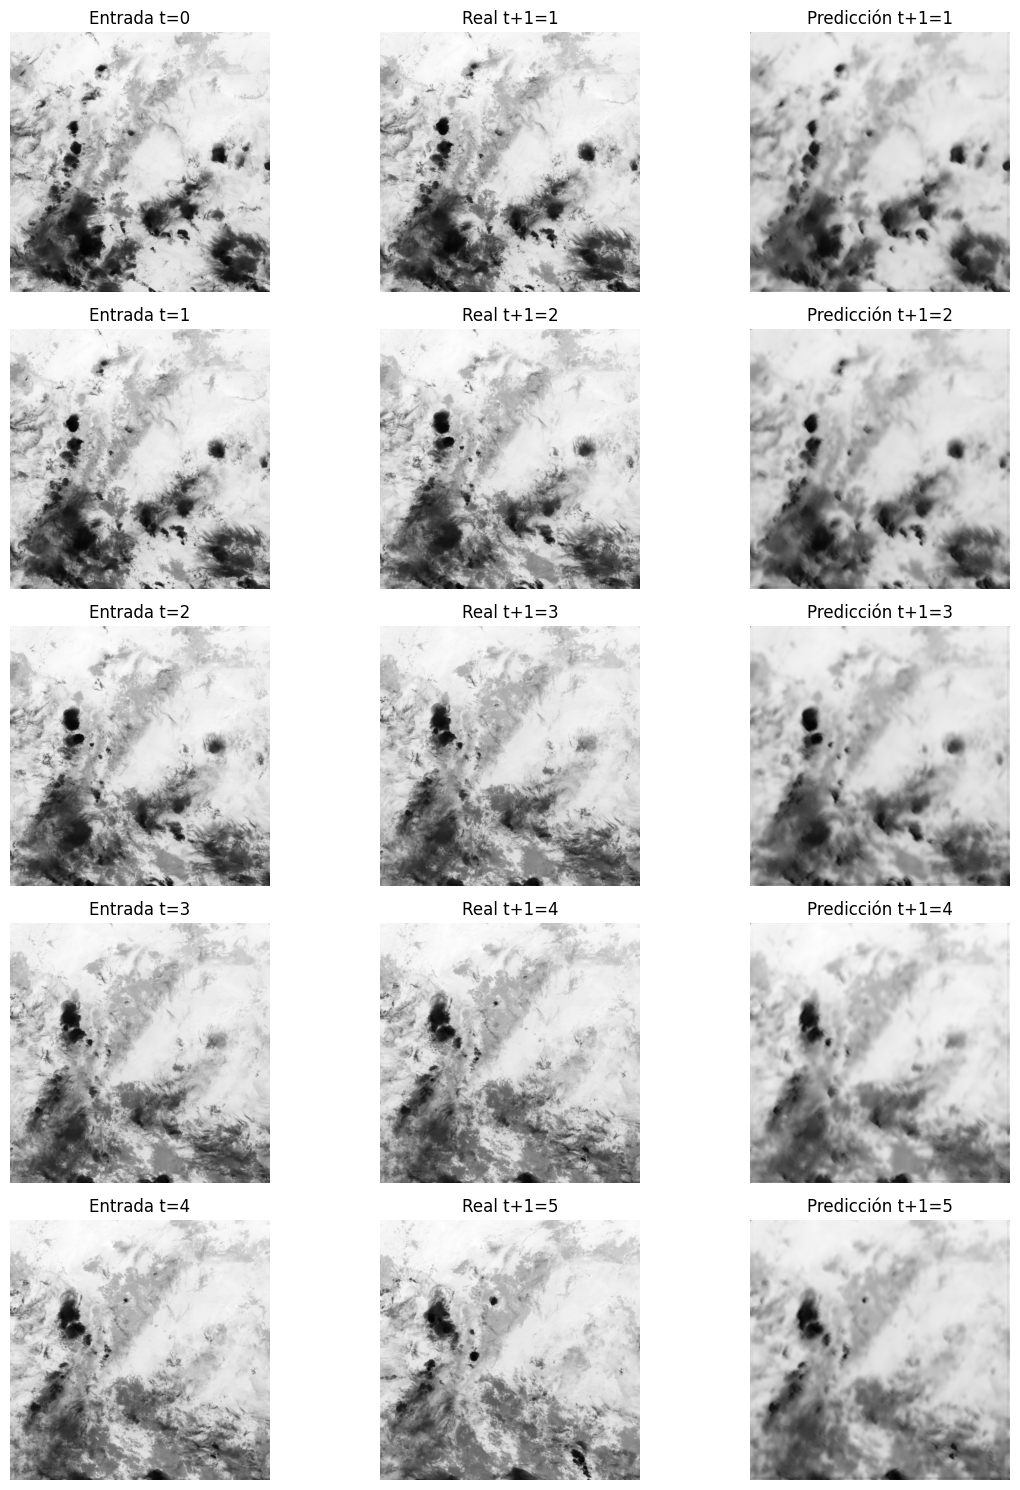

In [5]:
import matplotlib.pyplot as plt

# Generar predicciones
y_pred = model.predict(X)

# Mostrar algunas imágenes reales vs predichas
n = 5  # Número de ejemplos a mostrar
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X[i, ..., 0], cmap='gray')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y[i, ..., 0], cmap='gray')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred[i, ..., 0], cmap='gray')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()